# Desafio 2.2 Machine Learning Avançado


A base de dados “HR_Abandono.csv” contém um conjunto de características sobre colaboradores de uma empresa, tais como nível de satisfação com a empresa, média de horas mensais trabalhadas, tempo de empresa, acidente de trabalho, departamento, salário, entre outros atributos. Você, como cientista de dados, tem o desafio de seguir os passos abaixo para construir um modelo preditivo.

In [217]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, mannwhitneyu

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, make_scorer
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc

from imblearn.over_sampling import SMOTE

## Passo 1

O primeiro passo é a análise da consistência dos dados. Utilize a biblioteca do Pandas para subir a base de dados e realizar validações sobre os dados, tais como a verificação de valores nulos, duplicados, identificação de outliers e realizar tratativas caso seja necessário. Não se esqueça de explicar cada etapa de transformação aplicada aos dados caso seja necessário.

Após realizar a tratativa dos dados, é necessário namorar os dados e caprichar na análise estatística descritiva, como por exemplo entender a média das variáveis qualitativas, entre outras.

In [218]:
df = pd.read_csv('HR_Abandono.csv', sep = ';', decimal=',')

In [219]:
df.head()

,id,satisfaction_level,last_evaluation,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,num_project,depto
0,1,0.38,0.53,157,3,0,1,0,low,2,sales
1,2,0.80,0.86,262,6,0,1,0,medium,5,sales
2,3,0.11,0.88,272,4,0,1,0,medium,6,sales
3,4,0.72,0.87,223,5,0,1,0,low,5,sales
4,5,0.37,0.52,159,3,0,1,0,low,2,sales


In [220]:
df['depto'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [221]:
siglas = {'sales' : 'sales', 'accounting' : 'acc', 'hr' : 'hr', 'technical' : 'tech', 'support' : 'sup', 'management' : 'man',
          'IT' : 'it', 'product_mng' : 'prod', 'marketing' : 'mkt', 'RandD' : 'rand'}
df['depto'] = df['depto'].replace(siglas)

In [222]:
df.drop('id', axis=1, inplace=True)

In [223]:
df.shape

(14999, 10)

In [224]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   average_montly_hours   14999 non-null  int64  
 3   time_spend_company     14999 non-null  int64  
 4   Work_accident          14999 non-null  int64  
 5   left                   14999 non-null  int64  
 6   promotion_last_5years  14999 non-null  int64  
 7   salary                 14999 non-null  object 
 8   num_project            14999 non-null  int64  
 9   depto                  14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [225]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
salary,0
num_project,0
depto,0


In [226]:
df.duplicated().sum()

np.int64(3005)

In [227]:
df['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

In [228]:
df['depto'].unique()

array(['sales', 'acc', 'hr', 'tech', 'sup', 'man', 'it', 'prod', 'mkt',
       'rand'], dtype=object)

In [229]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years',
       'salary', 'num_project', 'depto'],
      dtype='object')

<Axes: xlabel='average_montly_hours'>

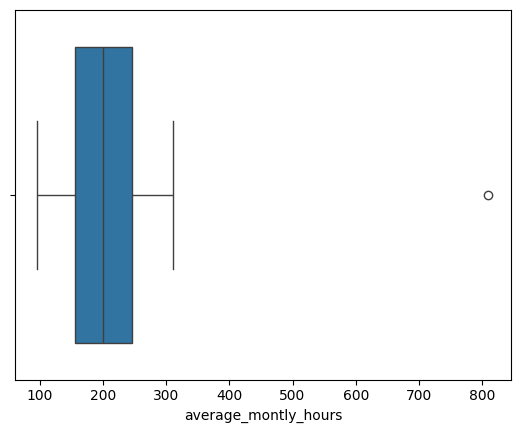

In [230]:
sns.boxplot(data=df, x='average_montly_hours')

In [231]:
df['average_montly_hours'].value_counts().head(20)

,count
average_montly_hours,
135,153
156,153
149,148
151,147
160,136
145,134
140,129
143,127
257,126


In [232]:
df['average_montly_hours'].value_counts()[310]

np.int64(17)

In [233]:
df.loc[df['average_montly_hours'] == 810, 'average_montly_hours'] = 310

<Axes: xlabel='average_montly_hours'>

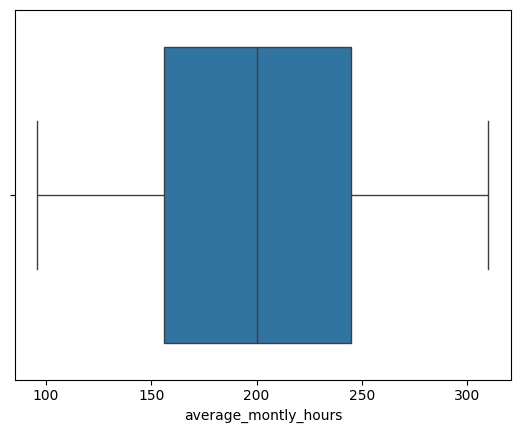

In [234]:
sns.boxplot(data=df, x='average_montly_hours')

<Axes: xlabel='time_spend_company'>

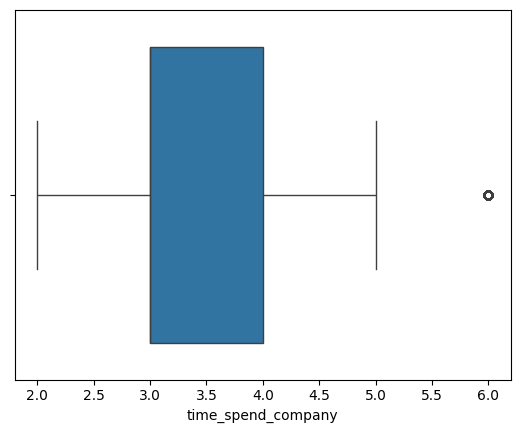

In [235]:
sns.boxplot(data=df, x='time_spend_company')

In [236]:
df['time_spend_company'].value_counts()

,count
time_spend_company,
3,6443
2,3244
4,2557
5,1473
6,1282


<Axes: xlabel='left'>

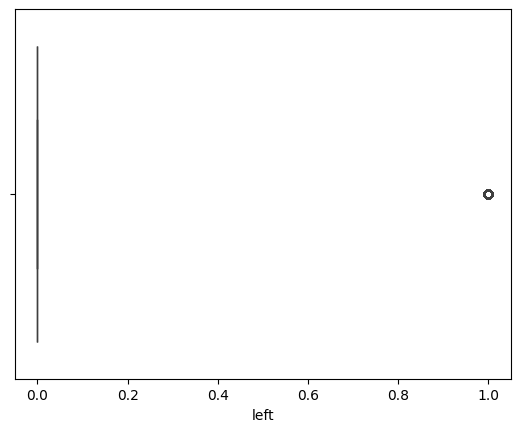

In [237]:
sns.boxplot(data=df, x='left')

In [238]:
df['left'].value_counts()

,count
left,
0,11428
1,3571


<Axes: xlabel='promotion_last_5years'>

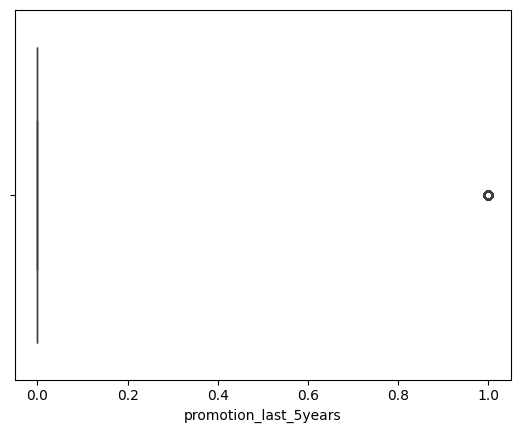

In [239]:
sns.boxplot(data=df, x='promotion_last_5years')

In [240]:
df['promotion_last_5years'].value_counts()

,count
promotion_last_5years,
0,14680
1,319


In [241]:
df.describe()

,satisfaction_level,last_evaluation,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,num_project
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612823,0.716102,201.050337,3.407027,0.144610,0.238083,0.021268,3.785986
std,0.248655,0.171169,49.943099,1.176120,0.351719,0.425924,0.144281,1.194539
min,0.010000,0.360000,96.000000,2.000000,0.000000,0.000000,0.000000,2.000000
25%,0.440000,0.560000,156.000000,3.000000,0.000000,0.000000,0.000000,3.000000
50%,0.640000,0.720000,200.000000,3.000000,0.000000,0.000000,0.000000,4.000000
75%,0.820000,0.870000,245.000000,4.000000,0.000000,0.000000,0.000000,5.000000
max,1.000000,1.000000,310.000000,6.000000,1.000000,1.000000,1.000000,6.000000


In [242]:
df['salary'].value_counts()

,count
salary,
low,7316
medium,6446
high,1237


In [243]:
df['depto'].value_counts()

,count
depto,
sales,4140
tech,2720
sup,2229
it,1227
prod,902
mkt,858
rand,787
acc,767
hr,739


## Passo 2

Utilize a biblioteca do matplotlib e seaborn para realizar uma bela análise de dados com storytelling. Faça perguntas para os dados e conte uma história, utilizando gráficos e realizando inferências para explicar cada uma das análises. A dica aqui é não economizar no uso de gráficos!

In [244]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years',
       'salary', 'num_project', 'depto'],
      dtype='object')

<Axes: xlabel='satisfaction_level', ylabel='last_evaluation'>

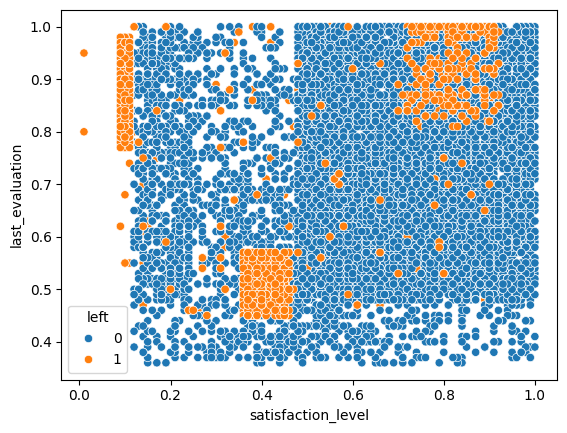

In [245]:
sns.scatterplot(data=df, x='satisfaction_level', y='last_evaluation', hue='left')

<Axes: xlabel='satisfaction_level', ylabel='average_montly_hours'>

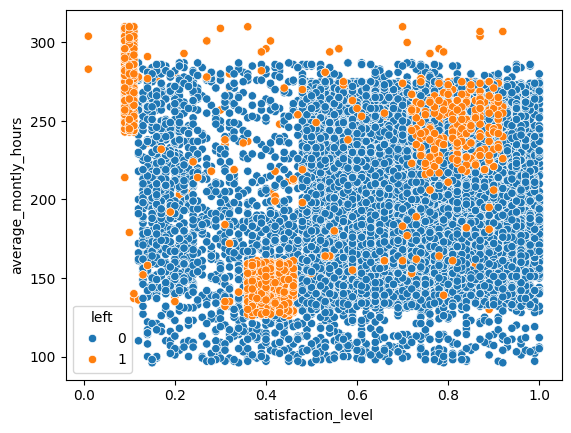

In [246]:
sns.scatterplot(data=df, x='satisfaction_level', y='average_montly_hours', hue='left')

<Axes: xlabel='time_spend_company', ylabel='satisfaction_level'>

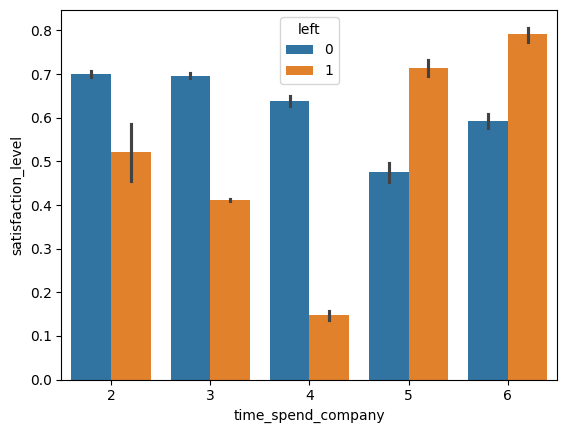

In [247]:
sns.barplot(data=df, x='time_spend_company', y='satisfaction_level', hue='left')

<Axes: xlabel='num_project', ylabel='satisfaction_level'>

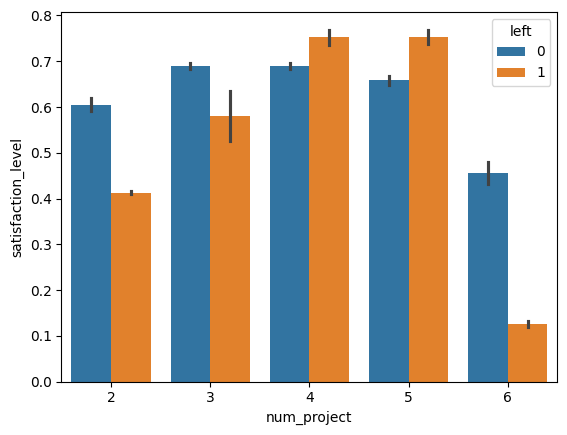

In [248]:
sns.barplot(data=df, x='num_project', y='satisfaction_level', hue='left')

<Axes: xlabel='last_evaluation', ylabel='average_montly_hours'>

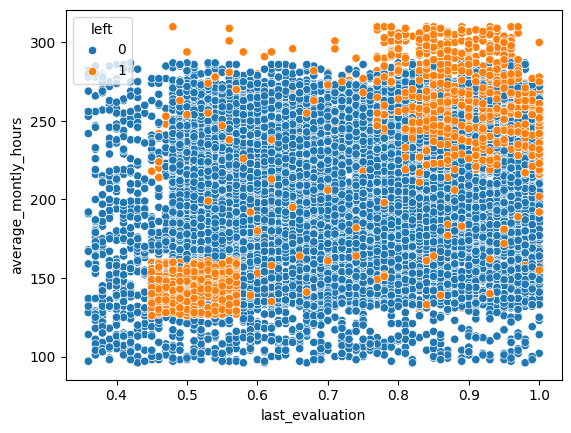

In [249]:
sns.scatterplot(data=df, x='last_evaluation', y='average_montly_hours', hue='left')

<Axes: xlabel='time_spend_company', ylabel='last_evaluation'>

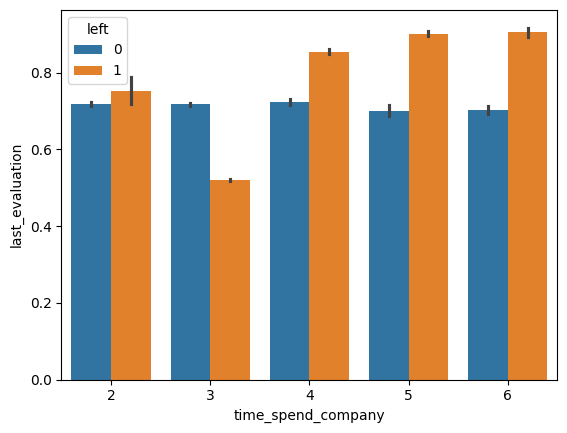

In [250]:
sns.barplot(data=df, x='time_spend_company', y='last_evaluation', hue='left')

<Axes: xlabel='time_spend_company', ylabel='average_montly_hours'>

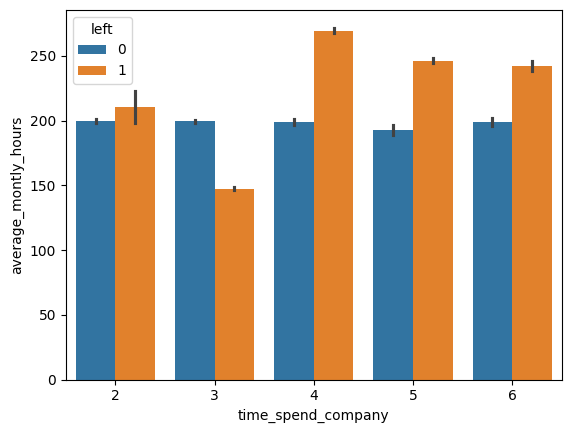

In [251]:
sns.barplot(data=df, x='time_spend_company', y='average_montly_hours', hue='left')

<Axes: xlabel='num_project', ylabel='average_montly_hours'>

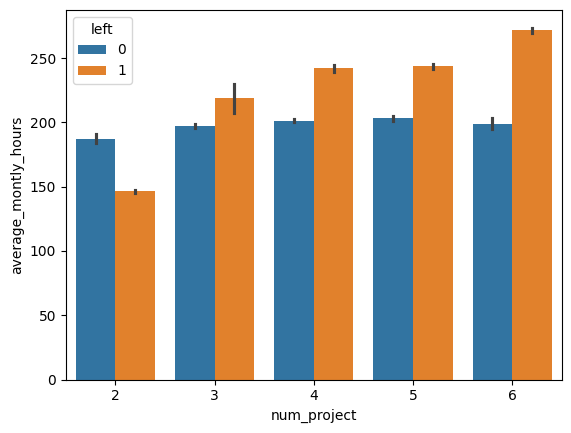

In [252]:
sns.barplot(data=df, x='num_project', y='average_montly_hours', hue='left')

<Axes: xlabel='Work_accident', ylabel='time_spend_company'>

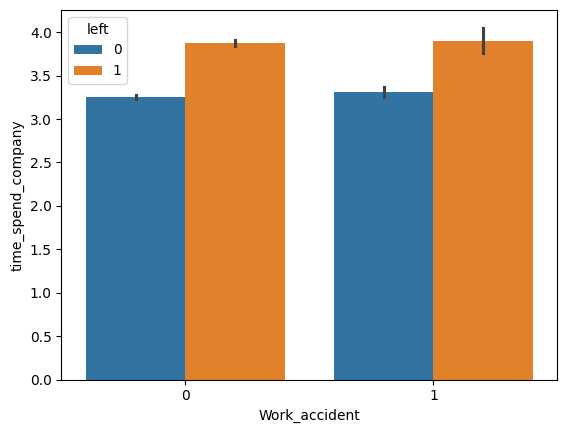

In [253]:
sns.barplot(data=df, x='Work_accident', y='time_spend_company', hue='left')

<Axes: xlabel='promotion_last_5years', ylabel='time_spend_company'>

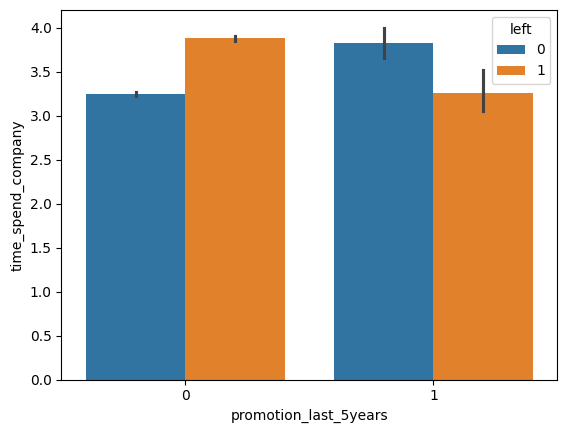

In [254]:
sns.barplot(data=df, x='promotion_last_5years', y='time_spend_company', hue='left')

<Axes: xlabel='salary', ylabel='time_spend_company'>

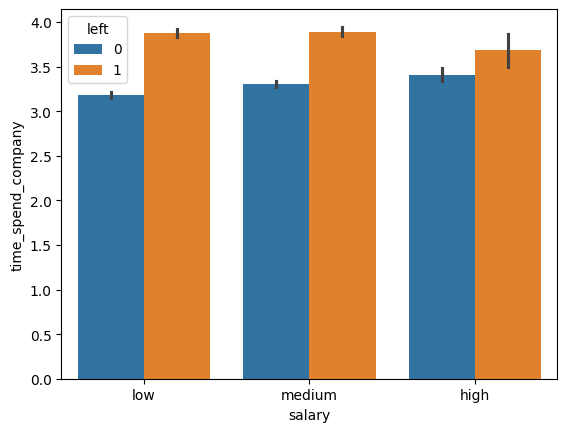

In [255]:
sns.barplot(data=df, x='salary', y='time_spend_company', hue='left')

<Axes: xlabel='promotion_last_5years', ylabel='Work_accident'>

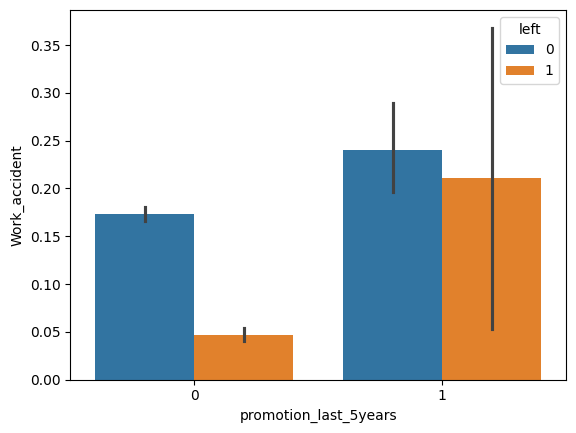

In [256]:
sns.barplot(data=df, x='promotion_last_5years', y='Work_accident', hue='left')

<Axes: xlabel='salary', ylabel='Work_accident'>

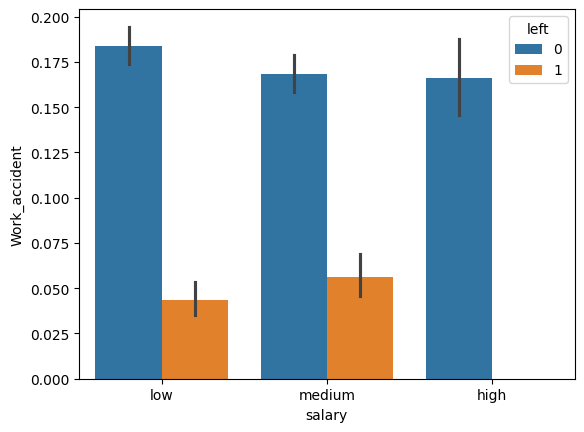

In [257]:
sns.barplot(data=df, x='salary', y='Work_accident', hue='left')

<Axes: xlabel='salary', ylabel='promotion_last_5years'>

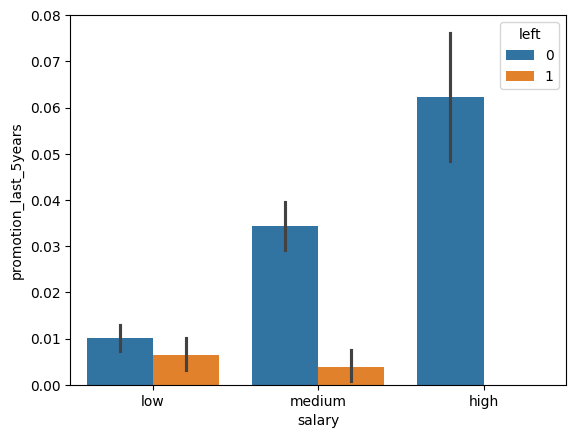

In [258]:
sns.barplot(data=df, x='salary', y='promotion_last_5years', hue='left')

<Axes: xlabel='depto', ylabel='promotion_last_5years'>

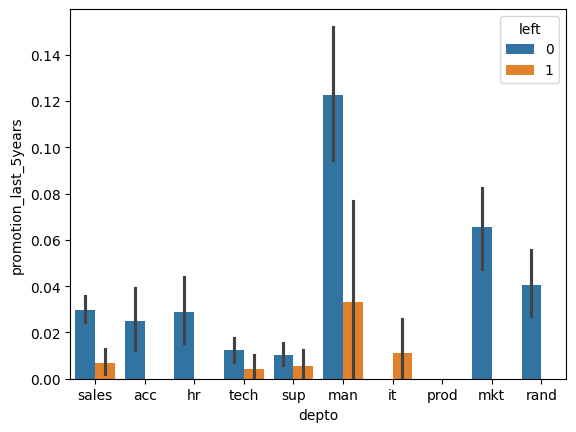

In [259]:
sns.barplot(data=df, x='depto', y='promotion_last_5years', hue='left')

## Passo 3

Com base em suas análises exploratórias, formule uma hipótese estatística (aqui é importante definir claramente a afirmação que será testada), com o objetivo de comprovar se a hipótese será aceita ou não. Valide o teste e explique se a hipótese foi aceita.

In [260]:
low = df[df['salary'] == 'low']
medium = df[df['salary'] != 'medium']
high = df[df['salary'] == 'high']

In [261]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'average_montly_hours',
       'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years',
       'salary', 'num_project', 'depto'],
      dtype='object')

<Axes: xlabel='average_montly_hours', ylabel='Count'>

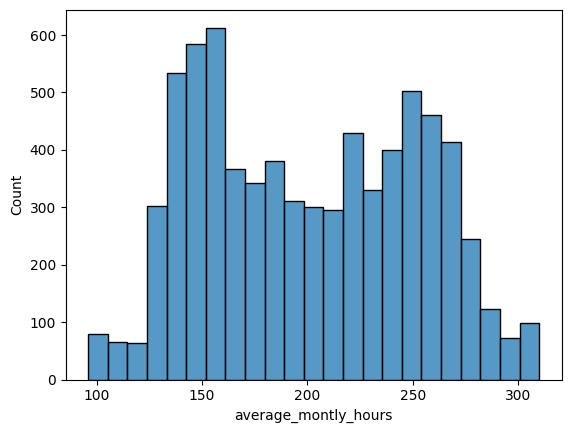

In [262]:
sns.histplot(data = low['average_montly_hours'])

<Axes: xlabel='average_montly_hours', ylabel='Count'>

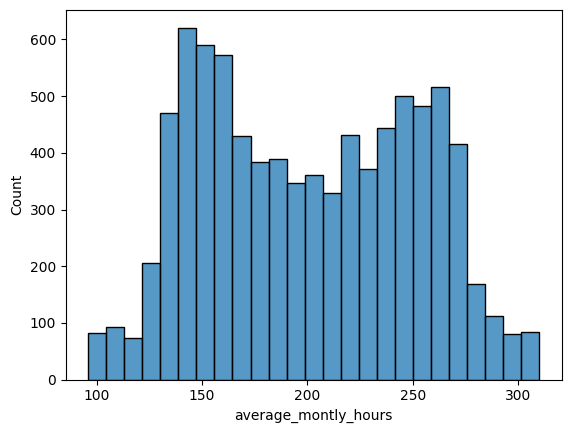

In [263]:
sns.histplot(data = medium['average_montly_hours'])

<Axes: xlabel='average_montly_hours', ylabel='Count'>

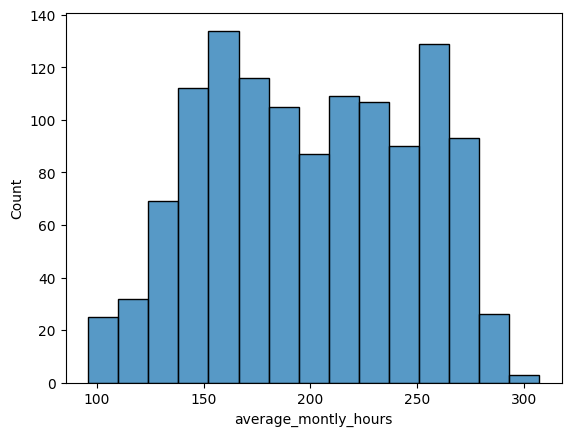

In [264]:
sns.histplot(data = high['average_montly_hours'])

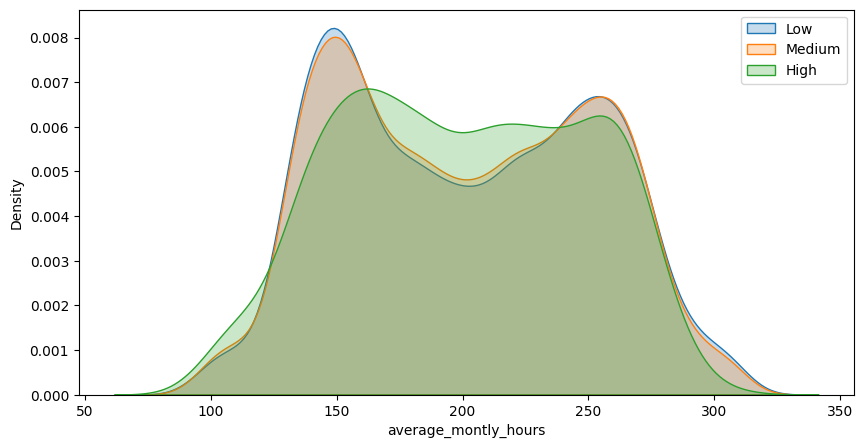

In [265]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=low['average_montly_hours'], label='Low', fill=True)
sns.kdeplot(data=medium['average_montly_hours'], label='Medium', fill=True)
sns.kdeplot(data=high['average_montly_hours'], label='High', fill=True)
plt.legend()

In [266]:
stat, p = shapiro(low['average_montly_hours'])
print('Estatística de Teste: {:.4f}, valor p: {}'.format(stat, p))
if p > 0.05:
    print('Não há evidência suficiente para rejeitar a hipótese de normalidade.')
else:
    print('A hipótese de normalidade é rejeitada.')

Estatística de Teste: 0.9599, valor p: 6.987004491004302e-41
A hipótese de normalidade é rejeitada.


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7316.
  res = hypotest_fun_out(*samples, **kwds)


In [267]:
stat, p = shapiro(medium['average_montly_hours'])
print('Estatística de Teste: {:.4f}, valor p: {}'.format(stat, p))
if p > 0.05:
    print('Não há evidência suficiente para rejeitar a hipótese de normalidade.')
else:
    print('A hipótese de normalidade é rejeitada.')

Estatística de Teste: 0.9624, valor p: 2.478993991781093e-42
A hipótese de normalidade é rejeitada.


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8553.
  res = hypotest_fun_out(*samples, **kwds)


In [268]:
stat, p = shapiro(high['average_montly_hours'])
print('Estatística de Teste: {:.4f}, valor p: {}'.format(stat, p))
if p > 0.05:
    print('Não há evidência suficiente para rejeitar a hipótese de normalidade.')
else:
    print('A hipótese de normalidade é rejeitada.')

Estatística de Teste: 0.9712, valor p: 5.6027314672963646e-15
A hipótese de normalidade é rejeitada.


In [269]:
stat, p = mannwhitneyu(low['average_montly_hours'].sample(len(low['average_montly_hours'])),
                       medium['average_montly_hours'].sample(len(medium['average_montly_hours'])),  alternative='greater')

print('Estatística de teste U: ', stat)
print('Valor p: ', p)

alpha = 0.05
if p < alpha:
    print('Diferença estatisticamente significante')
else:
    print('Não há diferença estatisticamente significante')

Estatística de teste U:  31304723.5
Valor p:  0.47526223167032045
Não há diferença estatisticamente significante


In [270]:
stat, p = mannwhitneyu(low['average_montly_hours'].sample(len(low['average_montly_hours'])),
                       high['average_montly_hours'].sample(len(high['average_montly_hours'])),  alternative='greater')

print('Estatística de teste U: ', stat)
print('Valor p: ', p)

alpha = 0.05
if p < alpha:
    print('Diferença estatisticamente significante')
else:
    print('Não há diferença estatisticamente significante')

Estatística de teste U:  4542795.5
Valor p:  0.41206653604293464
Não há diferença estatisticamente significante


## Passo 4

Identifique qual tipo de problema pode ser resolvido (supervisionado ou não supervisionado). Caso o modelo seja supervisionado, identifique a variável target.

In [271]:
df = pd.get_dummies(df, columns=['salary'])
df[[col for col in df.columns if col.startswith('salary_')]] = df[[col for col in df.columns if col.startswith('salary_')]].astype(int)

In [272]:
x = df.drop(columns=['left', 'depto'])
y = df['left'] #target

In [273]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

## Passo 5

Construa um modelo preditivo com os algoritmos disponíveis na biblioteca do Scikit-Learn e explique qual algoritmo você escolheu utilizar para solucionar o problema definido. Não se esqueça de esclarecer os hiperparâmetros utilizados.

In [274]:
df['left'].value_counts()

,count
left,
0,11428
1,3571


In [275]:
oversample = SMOTE()
x_train_os, y_train_os = oversample.fit_resample(x_train, y_train)

In [276]:
error = []

for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Mean Error')

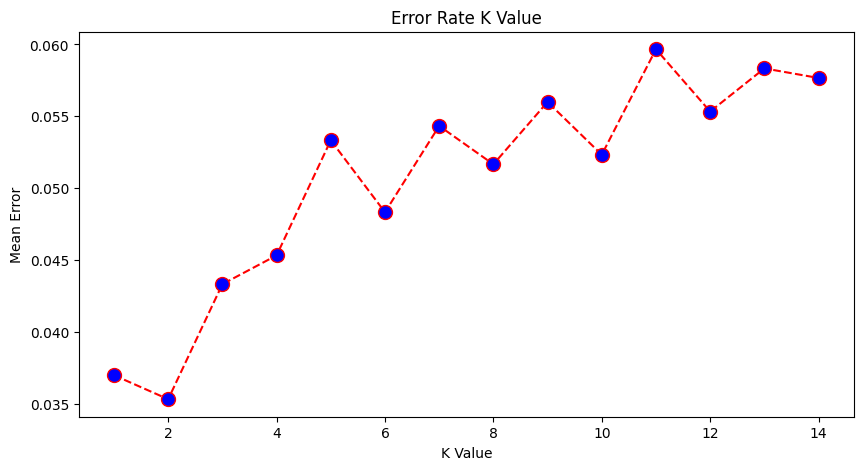

In [277]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [278]:
def AplicaValidacaoCruzada(x_axis, y_axis):

  kfold  = KFold(n_splits=10, shuffle=True)

  x = x_axis
  y = y_axis

  # KNN
  knn = KNeighborsClassifier(n_neighbors=2, metric= 'euclidean', weights='distance')
  knn.fit(x, y)

  # SVM
  svm = SVC()
  svm.fit(x, y)

  # RandomForest
  rf = RandomForestClassifier(random_state=7)
  rf.fit(x, y)

  # KFold
  knn_result = cross_val_score(knn, x, y, cv = kfold)
  svm_result = cross_val_score(svm, x, y, cv = kfold)
  rf_result = cross_val_score(rf, x, y, cv = kfold)

  dic_models = {
    "KNN": knn_result.mean(),
    "SVM": svm_result.mean(),
    "RF": rf_result.mean()
  }

  melhorModelo = max(dic_models, key=dic_models.get)

  print("KNN (R^2): {0}\nSVM (R^2): {1}\nRandom Forest (R^2): {2}".format(knn_result.mean(), svm_result.mean(), rf_result.mean()))
  print("O melhor modelo é : {0} com o valor: {1}".format(melhorModelo, dic_models[melhorModelo]))

In [279]:
AplicaValidacaoCruzada(x, y)

KNN (R^2): 0.9659311985768289
SVM (R^2): 0.7843184345118968
Random Forest (R^2): 0.992199199466311
O melhor modelo é : RF com o valor: 0.992199199466311


In [280]:
param_grid = {'n_neighbors':[2, 3],
              'weights': ['uniform', 'distance'],
              'metric':['cosine', 'euclidean', 'manhattan'],
             }

gs_metric = make_scorer(accuracy_score, greater_is_better=True)

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid=param_grid,
                    scoring=gs_metric,
                    cv=5, n_jobs=4, verbose=3)

grid.fit(x_train, y_train)
rf_params = grid.best_params_
print('KNN', rf_params)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
KNN {'metric': 'cosine', 'n_neighbors': 2, 'weights': 'distance'}


In [281]:
knn = KNeighborsClassifier(n_neighbors=5, metric= 'cosine', weights='distance')
scores = cross_val_score(knn, x, y, cv=5)

print("Acurácias por fold:", scores)
print("Acurácia média:", scores.mean())

Acurácias por fold: [0.97966667 0.953      0.96       0.986      0.97132377]
Acurácia média: 0.9699980882516395


In [282]:
knn.fit(x_train, y_train)
y_predito = knn.predict(x_test)

## Passo 6

Valide o modelo com uso de métricas estatísticas apropriadas para comprovar a eficácia do modelo.

<Figure size 1500x500 with 0 Axes>

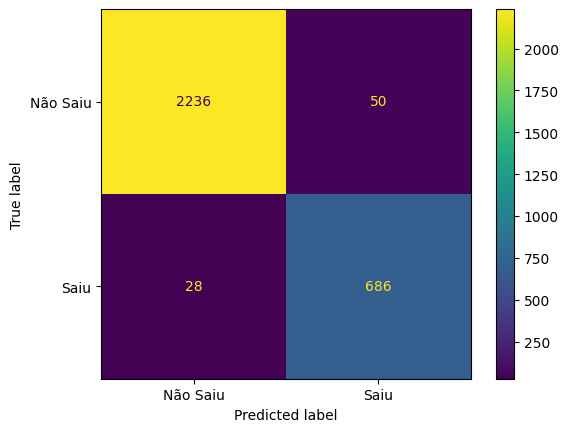

In [283]:
matriz_confusao = confusion_matrix(y_true = y_test,
                                   y_pred = y_predito,
                                   labels=[0,1])

# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao,
                              display_labels=['Não Saiu', 'Saiu'])
disp.plot(values_format='d')

In [284]:
print(classification_report(y_test, y_predito))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2286
           1       0.93      0.96      0.95       714

    accuracy                           0.97      3000
   macro avg       0.96      0.97      0.96      3000
weighted avg       0.97      0.97      0.97      3000



In [285]:
y_prob = knn.predict_proba(x_test)[:,1]

In [286]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc

np.float64(0.9826023585287132)

Text(0.5, 0, 'False Positive Rate')

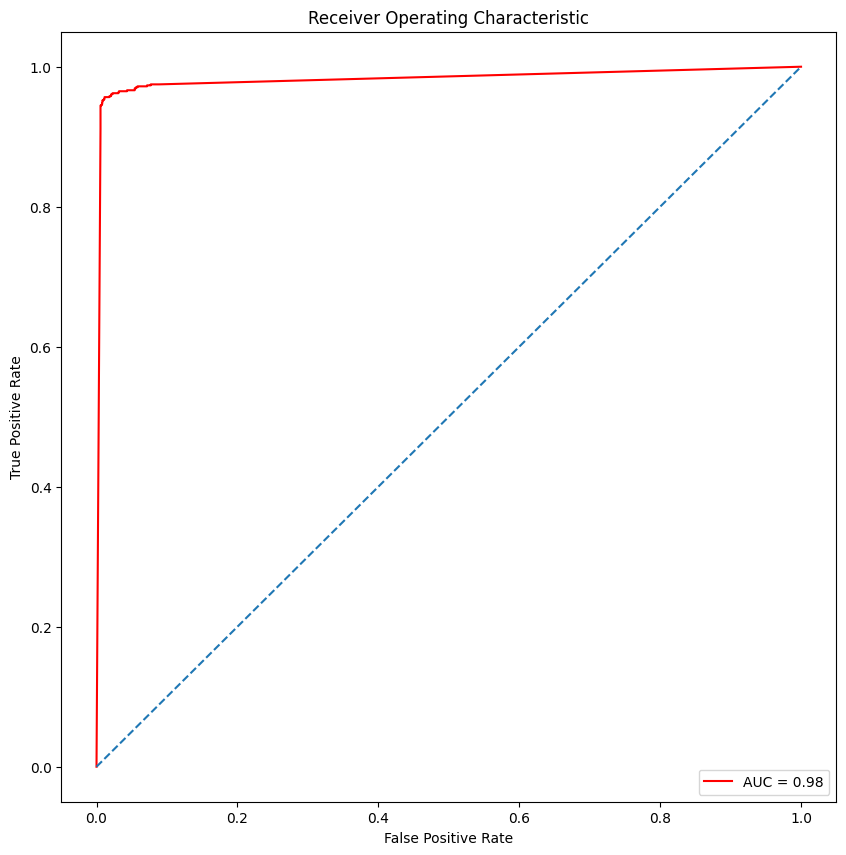

In [287]:
plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')